# Comparison

### 1. Settings

In [1]:
# imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# useful functions
def read_single_result(csv_path, model_name, representation_name):
    """
    Read a one-row CSV file containing final test metrics
    and add model and representation labels.
    """

    df = pd.read_csv(csv_path)

    df["model"] = model_name
    df["representation"] = representation_name

    return df


def save_table(df, filename, index=False):
    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)


def save_figure(filename, dpi=300):
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)

### 2. Results

In [4]:
results = []

# Random Forest - original best spectral feature set
results.append(
    read_single_result(
        TABS_DIR / "2a_rf_original_best_feature_set_test_metrics.csv",
        model_name="Random Forest",
        representation_name="Spectral features"
    )
)

# Random Forest - correlation-reduced spectral feature set
results.append(
    read_single_result(
        TABS_DIR / "2a_rf_correlation_reduced_feature_set_test_metrics.csv",
        model_name="Random Forest",
        representation_name="Correlation-reduced spectral features"
    )
)

# Random Forest - theta/beta ratio feature set
results.append(
    read_single_result(
        TABS_DIR / "2a_rf_theta_beta_ratio_feature_set_test_metrics.csv",
        model_name="Random Forest",
        representation_name="Theta/beta ratio features"
    )
)

In [5]:
# Logistic Regression - original best spectral feature set
results.append(
    read_single_result(
        TABS_DIR / "2b_logreg_original_best_feature_set_test_metrics.csv",
        model_name="Logistic Regression",
        representation_name="Spectral features"
    )
)

# Logistic Regression - correlation-reduced spectral features
results.append(
    read_single_result(
        TABS_DIR / "2b_logreg_correlation_reduced_feature_set_test_metrics.csv",
        model_name="Logistic Regression",
        representation_name="Correlation-reduced spectral features"
    )
)

# Logistic Regression - theta/beta ratio features
results.append(
    read_single_result(
        TABS_DIR / "2b_logreg_theta_beta_ratio_feature_set_test_metrics.csv",
        model_name="Logistic Regression",
        representation_name="Theta/beta ratio features"
    )
)

In [6]:
# Random Forest - functional connectivity
results.append(
    read_single_result(
        TABS_DIR / "4a_rf_connectivity_best_feature_set_test_metrics.csv",
        model_name="Random Forest",
        representation_name="Functional connectivity"
    )
)

# Logistic Regression - functional connectivity
results.append(
    read_single_result(
        TABS_DIR / "4a_logreg_connectivity_best_feature_set_test_metrics.csv",
        model_name="Logistic Regression",
        representation_name="Functional connectivity"
    )
)

In [7]:
model_comparison_df = pd.concat(
    results,
    ignore_index=True
)

columns_to_show = [
    "representation",
    "model",
    "feature_set",
    "n_features",
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

model_comparison_df = model_comparison_df[columns_to_show]

model_comparison_df = model_comparison_df.sort_values(
    "balanced_accuracy",
    ascending=False
)

save_table(
    model_comparison_df,
    "5_model_comparison_test_metrics.csv"
)

display(model_comparison_df)

Table saved to: outputs\tabs\5_model_comparison_test_metrics.csv


,representation,model,feature_set,n_features,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
6,Functional connectivity,Random Forest,Channel-level connectivity features,684,0.88,0.881410,0.916667,0.846154,0.880000,0.961538
7,Functional connectivity,Logistic Regression,Logistic Regression - Channel-level connectivi...,684,0.88,0.881410,0.916667,0.846154,0.880000,0.916667
5,Theta/beta ratio features,Logistic Regression,Logistic Regression - Theta/beta ratio feature...,19,0.76,0.756410,0.733333,0.846154,0.785714,0.730769
2,Theta/beta ratio features,Random Forest,Channel-level theta/beta ratio features,19,0.72,0.711538,0.666667,0.923077,0.774194,0.737179
1,Correlation-reduced spectral features,Random Forest,Correlation-reduced RF features,52,0.68,0.676282,0.666667,0.769231,0.714286,0.750000
0,Spectral features,Random Forest,All EEG features,120,0.64,0.637821,0.642857,0.692308,0.666667,0.730769
4,Correlation-reduced spectral features,Logistic Regression,Logistic Regression - Correlation-reduced feat...,52,0.52,0.519231,0.538462,0.538462,0.538462,0.538462
3,Spectral features,Logistic Regression,Logistic Regression - All EEG features,120,0.48,0.467949,0.500000,0.769231,0.606061,0.544872


### 3. Plots

In [8]:
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

comparison_long_df = model_comparison_df.melt(
    id_vars=["representation", "model", "feature_set", "n_features"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="value"
)

comparison_long_df["label"] = (
    comparison_long_df["representation"]
    + "\n"
    + comparison_long_df["model"]
)

display(comparison_long_df.head())

,representation,model,feature_set,n_features,metric,value,label
0,Functional connectivity,Random Forest,Channel-level connectivity features,684,accuracy,0.88,Functional connectivity\nRandom Forest
1,Functional connectivity,Logistic Regression,Logistic Regression - Channel-level connectivi...,684,accuracy,0.88,Functional connectivity\nLogistic Regression
2,Theta/beta ratio features,Logistic Regression,Logistic Regression - Theta/beta ratio feature...,19,accuracy,0.76,Theta/beta ratio features\nLogistic Regression
3,Theta/beta ratio features,Random Forest,Channel-level theta/beta ratio features,19,accuracy,0.72,Theta/beta ratio features\nRandom Forest
4,Correlation-reduced spectral features,Random Forest,Correlation-reduced RF features,52,accuracy,0.68,Correlation-reduced spectral features\nRandom ...


Figure saved to: outputs\figures\5_model_comparison_all_metrics.png


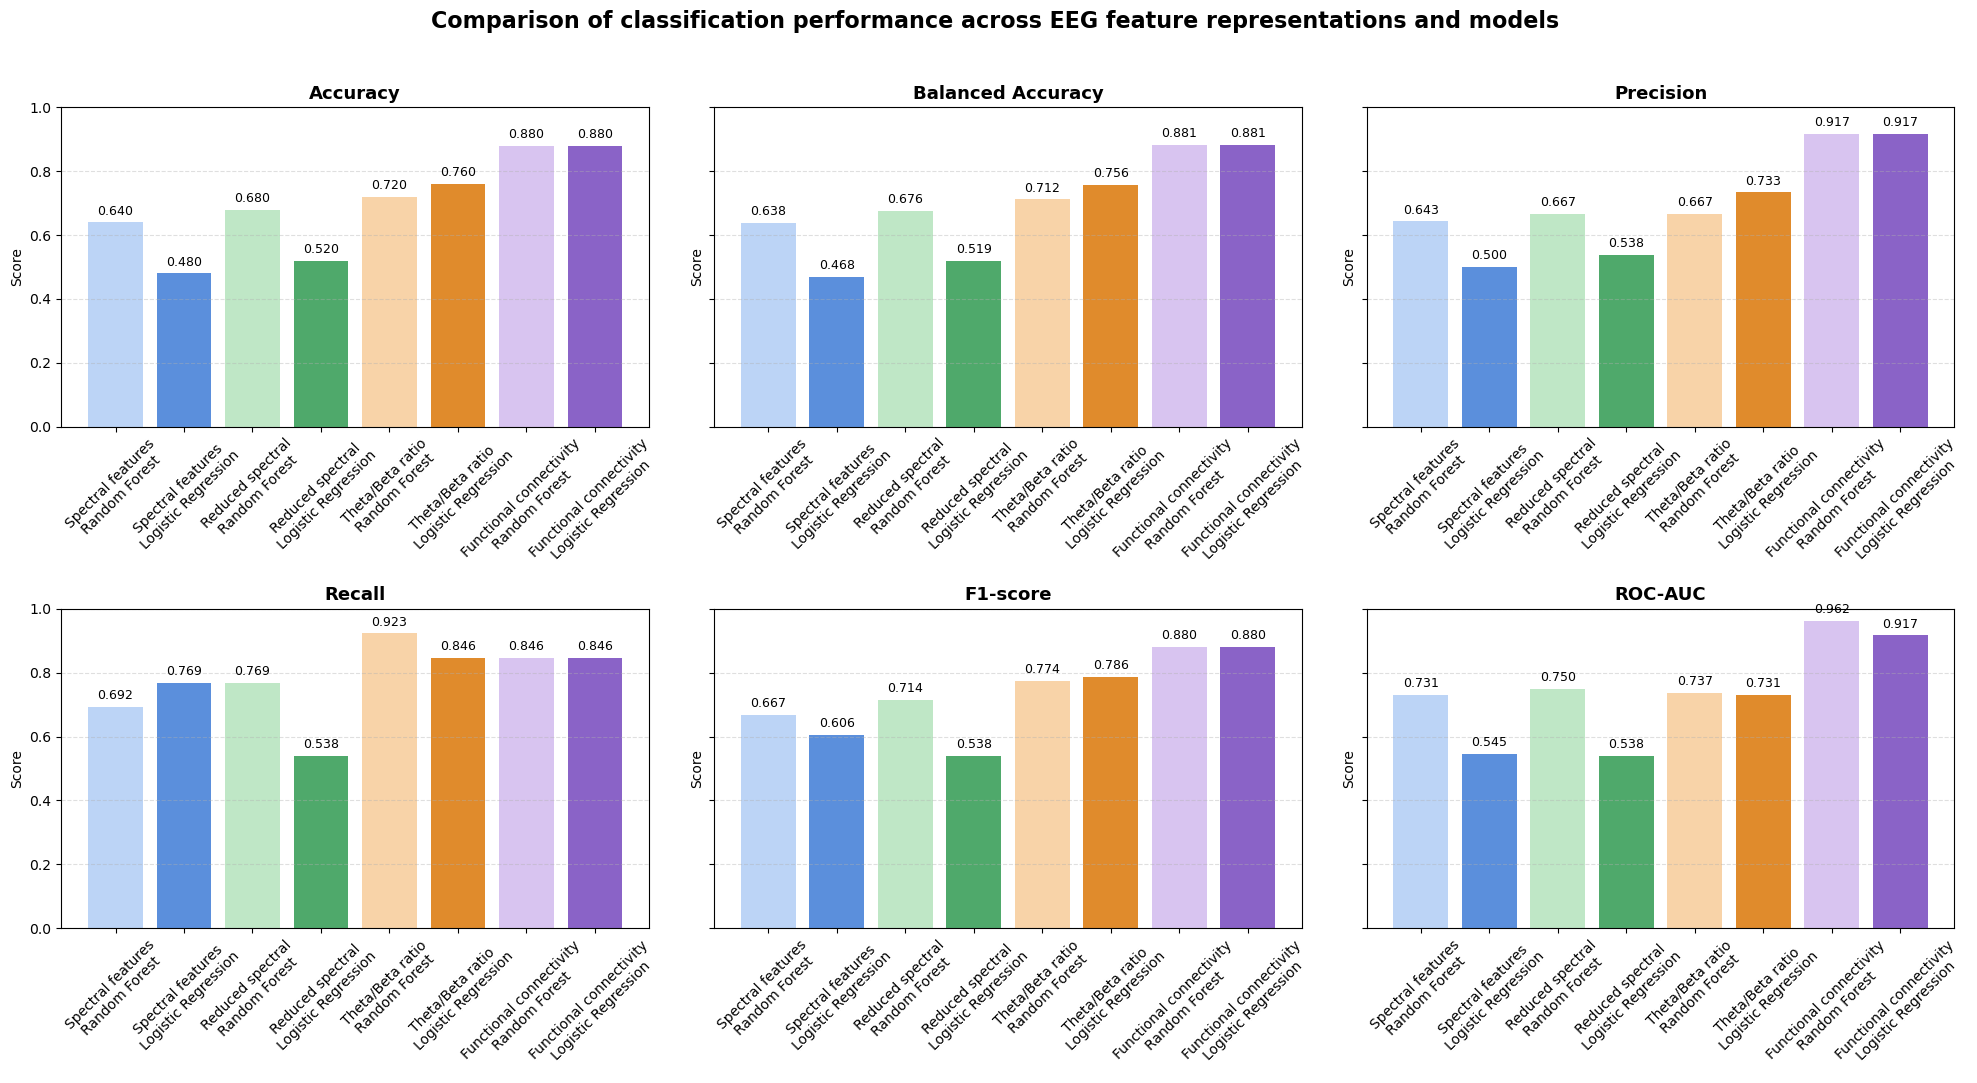

In [9]:
# Metrics to visualize
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

# Create combined label
comparison_long_df["plot_key"] = (
    comparison_long_df["representation"] + " | " + comparison_long_df["model"]
)

# Order of bars in all plots
plot_order = [
    "Spectral features | Random Forest",
    "Spectral features | Logistic Regression",
    "Correlation-reduced spectral features | Random Forest",
    "Correlation-reduced spectral features | Logistic Regression",
    "Theta/beta ratio features | Random Forest",
    "Theta/beta ratio features | Logistic Regression",
    "Functional connectivity | Random Forest",
    "Functional connectivity | Logistic Regression",
]

# Keep only the rows that exist and preserve the desired order
existing_order = [
    label for label in plot_order
    if label in comparison_long_df["plot_key"].unique()
]

# Short labels for x-axis
label_map = {
    "Spectral features | Random Forest": "Spectral features\nRandom Forest",
    "Spectral features | Logistic Regression": "Spectral features\nLogistic Regression",
    "Correlation-reduced spectral features | Random Forest": "Reduced spectral\nRandom Forest",
    "Correlation-reduced spectral features | Logistic Regression": "Reduced spectral\nLogistic Regression",
    "Theta/beta ratio features | Random Forest": "Theta/Beta ratio\nRandom Forest",
    "Theta/beta ratio features | Logistic Regression": "Theta/Beta ratio\nLogistic Regression",
    "Functional connectivity | Random Forest": "Functional connectivity\nRandom Forest",
    "Functional connectivity | Logistic Regression": "Functional connectivity\nLogistic Regression",
}

# Color scheme:
# same family for same feature set
# pastel for Random Forest, stronger tone for Logistic Regression
color_map = {
    "Spectral features | Random Forest": "#bcd4f6",
    "Spectral features | Logistic Regression": "#5b8fdc",

    "Correlation-reduced spectral features | Random Forest": "#bfe7c6",
    "Correlation-reduced spectral features | Logistic Regression": "#4fa96b",

    "Theta/beta ratio features | Random Forest": "#f8d3a8",
    "Theta/beta ratio features | Logistic Regression": "#e08b2c",

    "Functional connectivity | Random Forest": "#d8c4f0",
    "Functional connectivity | Logistic Regression": "#8a63c7",
}

# Better titles for each metric
metric_title_map = {
    "accuracy": "Accuracy",
    "balanced_accuracy": "Balanced Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1-score",
    "roc_auc": "ROC-AUC"
}

fig, axes = plt.subplots(2, 3, figsize=(20, 11), sharey=True)
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):

    metric_df = comparison_long_df[
        comparison_long_df["metric"] == metric
    ].copy()

    metric_df["plot_key"] = pd.Categorical(
        metric_df["plot_key"],
        categories=existing_order,
        ordered=True
    )

    metric_df = metric_df.sort_values("plot_key")

    bar_colors = [color_map[label] for label in metric_df["plot_key"]]
    x_labels = [label_map[label] for label in metric_df["plot_key"]]

    bars = ax.bar(
        x_labels,
        metric_df["value"],
        color=bar_colors
    )

    ax.set_title(metric_title_map[metric], fontsize=13, fontweight="bold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.tick_params(axis="x", rotation=45)

    # Optional: write the value above each bar
    for bar, value in zip(bars, metric_df["value"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    "Comparison of classification performance across EEG feature representations and models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

save_figure("5_model_comparison_all_metrics.png")

plt.show()